# Exon Inclusion Analysis

In [1]:
!pip install ipykernel
!python -m ipykernel install --user --name finalproject --display-name "Python (final project)"

Installed kernelspec finalproject in /home/biouser/.local/share/jupyter/kernels/finalproject


In [2]:
## 0. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy.stats import spearmanr, bootstrap
from gtfparse import read_gtf
import pysam  
from matplotlib.colors import LinearSegmentedColormap
from functions import (
    load_type_neurons,
    compute_spearman_corr,
    spearman_corr_labels,
)

## 1. Load Data
- Load `altExonUsage_devel_type.gz`
- Filter only column with `Neuron` 
- Combine `Exon` and `Gene` to `GE` (`Exon::Gene`)

In [3]:
type_neurons = load_type_neurons("../../data/altExonUsage_devel_type.gz")
type_neurons.head(20)

,P14_Hippocampus_ExciteNeuron,P14_Hippocampus_InhibNeuron,P14_VisCortex_ExciteNeuron,P14_VisCortex_InhibNeuron,P21_Hippocampus_ExciteNeuron,P21_Hippocampus_InhibNeuron,P21_VisCortex_ExciteNeuron,P21_VisCortex_InhibNeuron,P28_Hippocampus_ExciteNeuron,P28_Hippocampus_InhibNeuron,P28_VisCortex_ExciteNeuron,P28_VisCortex_InhibNeuron,P56_Hippocampus_ExciteNeuron,P56_Hippocampus_InhibNeuron,P56_VisCortex_ExciteNeuron,P56_VisCortex_InhibNeuron
GE,,,,,,,,,,,,,,,,
chr1_162273620_162273649_-::ENSMUSG00000040265.16,0.032520,0.000000,0.008152,0.000000,0.049351,0.024000,0.000000,0.000000,0.015544,0.007812,0.001163,0.000000,0.015831,0.026316,0.005181,0.001821
chr1_186690721_186690804_-::ENSMUSG00000039239.14,0.000000,NaN,NaN,NaN,0.075472,NaN,NaN,NaN,0.083333,NaN,NaN,NaN,0.139073,NaN,0.019608,0.125000
chr1_172286198_172286396_-::ENSMUSG00000007097.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.818182,NaN
chr1_83384894_83384972_-::ENSMUSG00000026163.17,0.608364,0.642140,0.707604,0.657718,0.631307,0.707113,0.767779,0.776471,0.670919,0.666667,0.789824,0.805970,0.641826,0.694915,0.781662,0.712150
chr1_172279313_172279467_-::ENSMUSG00000007097.14,1.000000,NaN,1.000000,NaN,0.823529,NaN,0.823529,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,0.965517,NaN
chr1_163253977_163254048_-::ENSMUSG00000026586.16,0.545455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chr1_172287200_172287468_-::ENSMUSG00000007097.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chr1_16486020_16486150_-::ENSMUSG00000025920.19,0.204724,0.032967,0.240229,0.097222,0.222116,0.230769,0.275465,0.102564,0.223958,0.000000,0.230177,0.132075,0.218418,0.050633,0.220895,0.145867
chr1_162675605_162675841_-::ENSMUSG00000040225.15,0.812834,0.714286,0.824022,0.848485,0.891247,0.795455,0.818493,0.914286,0.869822,1.000000,0.841040,NaN,0.950530,0.840000,0.900850,0.959184


## 2. Performn Pairwise Correlation

- Remove rows with missing data `NaN`
- Compute Spearman correlation matrix

In [4]:
CN = compute_spearman_corr(type_neurons)
CN

,P14_HIPP_Excite,P14_HIPP_Inhib,P14_VIS_Excite,P14_VIS_Inhib,P21_HIPP_Excite,P21_HIPP_Inhib,P21_VIS_Excite,P21_VIS_Inhib,P28_HIPP_Excite,P28_HIPP_Inhib,P28_VIS_Excite,P28_VIS_Inhib,P56_HIPP_Excite,P56_HIPP_Inhib,P56_VIS_Excite,P56_VIS_Inhib
P14_HIPP_Excite,1.000000,0.865320,0.909911,0.886845,0.853609,0.841284,0.821143,0.845471,0.849383,0.841355,0.851881,0.817556,0.891090,0.885976,0.828041,0.816164
P14_HIPP_Inhib,0.865320,1.000000,0.852621,0.899736,0.843048,0.884450,0.814208,0.847335,0.830215,0.866666,0.819943,0.838889,0.836201,0.896754,0.813307,0.869893
P14_VIS_Excite,0.909911,0.852621,1.000000,0.910102,0.830537,0.830371,0.810601,0.866398,0.828769,0.833890,0.855997,0.821240,0.882145,0.870460,0.833206,0.823089
P14_VIS_Inhib,0.886845,0.899736,0.910102,1.000000,0.877425,0.881019,0.870836,0.886242,0.856335,0.864176,0.869230,0.900208,0.861776,0.893214,0.864582,0.898332
P21_HIPP_Excite,0.853609,0.843048,0.830537,0.877425,1.000000,0.861511,0.813749,0.879860,0.766540,0.811592,0.726914,0.761101,0.821703,0.885722,0.807427,0.833759
P21_HIPP_Inhib,0.841284,0.884450,0.830371,0.881019,0.861511,1.000000,0.844983,0.901320,0.825075,0.878993,0.811337,0.875430,0.825536,0.896380,0.837813,0.890832
P21_VIS_Excite,0.821143,0.814208,0.810601,0.870836,0.813749,0.844983,1.000000,0.889425,0.728493,0.789257,0.724341,0.785212,0.787906,0.869884,0.830261,0.819163
P21_VIS_Inhib,0.845471,0.847335,0.866398,0.886242,0.879860,0.901320,0.889425,1.000000,0.849540,0.847341,0.861349,0.902924,0.855445,0.882308,0.880106,0.913320
P28_HIPP_Excite,0.849383,0.830215,0.828769,0.856335,0.766540,0.825075,0.728493,0.849540,1.000000,0.840163,0.814149,0.816738,0.863503,0.884956,0.749237,0.770761
P28_HIPP_Inhib,0.841355,0.866666,0.833890,0.864176,0.811592,0.878993,0.789257,0.847341,0.840163,1.000000,0.827930,0.871407,0.805134,0.885399,0.803124,0.851962


## 3. Pairwise Correlation for Excitatory and Inhibitory Types

- Extract metadata from the table's index to create labels for the heat map
    - `Age`, `Region`, `Type` 
- Assign 

In [5]:
# Create labels for the heatmap
cnn = spearman_corr_labels(CN)
cnn

,CT,Age,Region,Type
0,P14_HIPP_Excite,P14,HIPP,Excite
1,P14_HIPP_Inhib,P14,HIPP,Inhib
2,P14_VIS_Excite,P14,VIS,Excite
3,P14_VIS_Inhib,P14,VIS,Inhib
4,P21_HIPP_Excite,P21,HIPP,Excite
5,P21_HIPP_Inhib,P21,HIPP,Inhib
6,P21_VIS_Excite,P21,VIS,Excite
7,P21_VIS_Inhib,P21,VIS,Inhib
8,P28_HIPP_Excite,P28,HIPP,Excite
9,P28_HIPP_Inhib,P28,HIPP,Inhib


In [6]:
## Define colour palettes

# Ages 
ages = ["P14", "P21", "P28", "P56"]
ages_colour = ["#ae3b24", "#c8812a", "#56632c" ,"#f68d62"]
ages_palette = dict(zip(ages, ages_colour))

# Regions
regions = ["VIS", "HIPP"]
regions_colour = ["#ddbbc6", "#fdc681"]
regions_palette = dict(zip(regions, regions_colour))

# Cell types
cts = ["Excite", "Inhib"]
cts_colour = ["#ffcc5c", "#65c3ba"]
cts_palette = dict(zip(cts, cts_colour))

/tmp/ipykernel_277841/31473300.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_full = cm.get_cmap("magma")


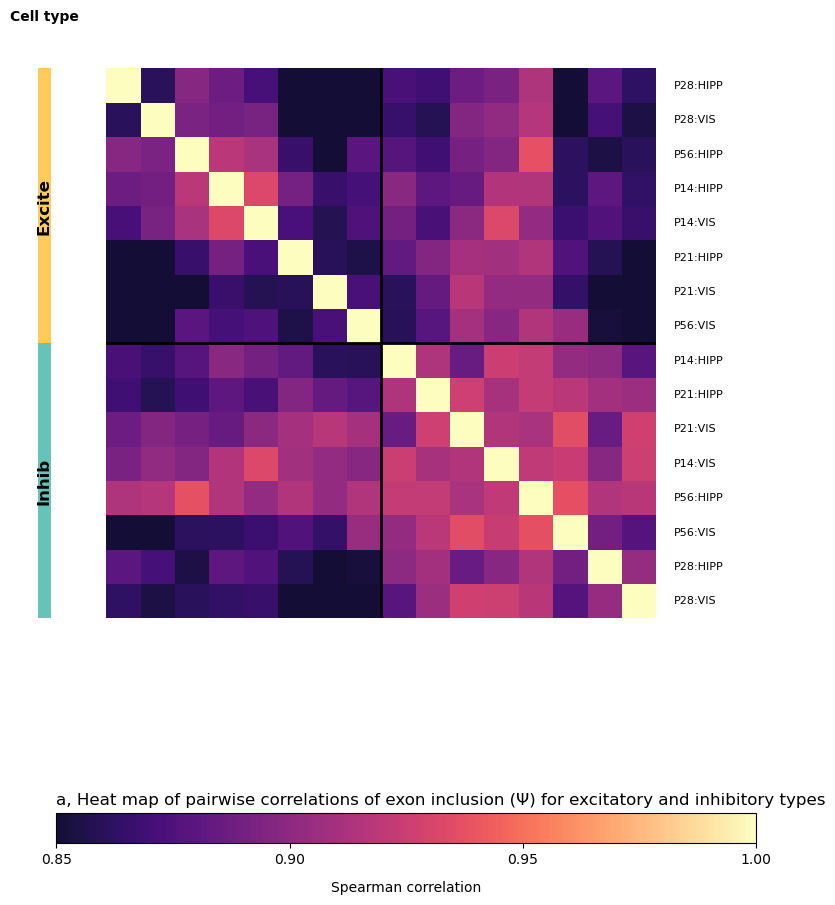

In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize, LinearSegmentedColormap, ListedColormap
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from scipy.spatial.distance import pdist, squareform
from matplotlib.patches import Rectangle

# ---------------------------
# Step 1: Split cell types
# ---------------------------
excite_rows = cnn[cnn["Type"] == "Excite"]["CT"].tolist()
inhib_rows = cnn[cnn["Type"] == "Inhib"]["CT"].tolist()

# ---------------------------
# Step 2: Hierarchical clustering within each group (rows)
# ---------------------------
def cluster_order(mat):
    # linkage
    Z = linkage(mat, method='average', metric='euclidean')
    # order of leaves
    idx = leaves_list(Z)
    return idx, Z

# Get clustering order for Excite
CN_excite = CN.loc[excite_rows, excite_rows]
# Compute distance matrix: 1 - correlation
dist_excite = 1 - CN_excite

# Convert to condensed distance matrix
condensed_excite = squareform(dist_excite.values)

# Hierarchical clustering
Z_excite = linkage(condensed_excite, method='average')

# Get leaves order
excite_idx = leaves_list(Z_excite)
excite_order = [excite_rows[i] for i in excite_idx]

# Get clustering order for Inhib
CN_inhib = CN.loc[inhib_rows, inhib_rows]
inhib_idx, inhib_link = cluster_order(CN_inhib)
inhib_order = [inhib_rows[i] for i in inhib_idx]

# Combine overall row order: Excite first, then Inhib
row_order = excite_order + inhib_order
col_order = row_order  # same order for columns

CN_ordered = CN.loc[row_order, col_order]

# ---------------------------
# Step 3: Compute top-level linkage between the 2 groups
# ---------------------------
# Calculate mean correlation profiles for each group
group_means = pd.DataFrame({
    "Excite": CN_ordered.loc[excite_order].mean(axis=1),
    "Inhib": CN_ordered.loc[inhib_order].mean(axis=1)
})

# Link the two groups (top-level linkage)
top_linkage = linkage(np.array([group_means["Excite"].mean(), group_means["Inhib"].mean()]).reshape(-1,1), method='average')

# ---------------------------
# Step 3: Create figure and axes for 4 sub-heatmaps
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 10))

# Color map (continuous magma)
cmap_full = cm.get_cmap("magma")

# Function to truncate colormap: start at 0.5 (brighter) to 1.0
def truncate_colormap(cmap, minval, maxval, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return LinearSegmentedColormap.from_list("trunc_" + cmap.name, new_colors)

cmap= truncate_colormap(cmap_full, 0.1, 1.0)

# Plot the full heatmap (we will mask quadrants to show sub-heatmaps clearly)
sns.heatmap(
    CN_ordered,
    ax=ax,
    cmap=cmap,
    vmin=0.8,
    vmax=1.0,
    square=True,
    cbar=False,
    xticklabels=False,
    yticklabels=False
)

# ---------------------------
# Step 4: Draw left cell type blocks with dendrogram
# ---------------------------
# Calculate dendrogram connecting Excite/Inhib groups
link_matrix = linkage(np.array([0]*len(row_order)).reshape(-1,1), method='average')  # dummy to connect 2 main blocks

# Draw left blocks
def add_celltype_blocks(ax, start_idx, end_idx, color, label):
    height = end_idx - start_idx + 1
    rect = Rectangle((-2, start_idx), 0.4, height, facecolor=color, edgecolor='none', transform=ax.transData, clip_on=False)
    ax.add_patch(rect)
    ax.text(-1.8, start_idx + height/2, label, rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')

add_celltype_blocks(ax, 0, len(excite_order)-1, cts_palette["Excite"], "Excite")
add_celltype_blocks(ax, len(excite_order), len(row_order)-1, cts_palette["Inhib"], "Inhib")

# Add axis label "Cell type" below the blocks
ax.text(-1.8, -1.5, "Cell type", ha='center', va='center', fontsize=10, fontweight='bold')

# ---------------------------
# Step 6: Dendrogram connecting Excite/Inhib blocks
# ---------------------------
# Compute the x,y coordinates for the top-level dendrogram
x0 = -2.0  # left of color blocks
y_excite = (0 + len(excite_order)-1)/2
y_inhib = (len(excite_order) + len(row_order)-1)/2
# Draw top-level linkage line
ax.plot([x0-0.1, x0-0.1], [y_excite, y_inhib], color='black', lw=2)  # vertical line connecting blocks
ax.plot([x0-0.2, x0-0.1], [y_excite, y_excite], color='black', lw=2)    # horizontal Excite branch
ax.plot([x0-0.2, x0-0.1], [y_inhib, y_inhib], color='black', lw=2)      # horizontal Inhib branch

# ---------------------------
# Step 5: Right-hand row annotation (Age:Region)
# ---------------------------
for i, row_name in enumerate(row_order):
    age = cnn.loc[cnn["CT"] == row_name, "Age"].iat[0]
    region = cnn.loc[cnn["CT"] == row_name, "Region"].iat[0]
    ax.text(len(row_order) + 0.5, i + 0.5, f"{age}:{region}", va='center', ha='left', fontsize=8)

# ---------------------------
# Step 6: Draw separation lines for quadrants
# ---------------------------
ax.axhline(len(excite_order), color='black', linewidth=2)
ax.axvline(len(excite_order), color='black', linewidth=2)

# ---------------------------
# Step 7: Add continuous magma colorbar below
# ---------------------------
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=Normalize(vmin=0.85, vmax=1.0))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Spearman correlation", labelpad=10)
cbar.set_ticks([0.85, 0.9, 0.95, 1.0])

# ---------------------------
# Step 8: Title
# ---------------------------
plt.title("a, Heat map of pairwise correlations of exon inclusion (Ψ) for excitatory and inhibitory types", fontsize=12, loc='left')

plt.subplots_adjust(left=0.2, right=0.75, top=0.95, bottom=0.15)
plt.show()
